# [LAB-06] 2-2. Line Plot 옵션 설정 - 연습문제

## Covid19 확진자 수 변동 추이 시각화

`covid19_active` 데이터는 2022년 5월 1일부터 2023년 5월 31일까지 서울과 전국의 Covid19 일일 확진자 수를 기록한 데이터이다. 

조사 기간동안 서울과 전국의 확진자 수가 어떻게 변화하고 있는지에 대한 추이를 시각화 하고 시각화 결과에서 얻을 수 있는 객관적 사실을 하나 이상 서술하시오.

## 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot
from pandas import melt
import seaborn as sb

### 2. 데이터 가져오기

In [2]:
df = load_data('covid19_active')
df

📚 2022년 5월 1일부터 2023년 5월 31일까지 서울과 전국의 Covid19 일일 확진자 수를 기록한 데이터 (출처: 서울시)


,서울시 일일 확진,전국 일일 확진
기준일,,
2023-05-31,5987.000,24411.000
2023-05-30,3326.000,13529.000
2023-05-29,1393.000,6868.000
2023-05-28,1393.000,6868.000
2023-05-27,4078.000,17796.000
...,...,...
2022-05-05,6645.000,42296.000
2022-05-04,7436.000,49064.000
2022-05-03,8709.000,51131.000


## 요구사항 해결

### 데이터 전처리 (1) - 인덱스 해제

In [3]:
df2 = df.reset_index()
df2.head()

,기준일,서울시 일일 확진,전국 일일 확진
0,2023-05-31,5987.000,24411.000
1,2023-05-30,3326.000,13529.000
2,2023-05-29,1393.000,6868.000
3,2023-05-28,1393.000,6868.000
4,2023-05-27,4078.000,17796.000


### 데이터 전처리 (2) - 데이터 재구조화

In [4]:
df3 = melt(df2, id_vars='기준일', value_vars=['서울시 일일 확진', '전국 일일 확진'],
           var_name='구분', value_name='확진자 수')
df3.head()

,기준일,구분,확진자 수
0,2023-05-31,서울시 일일 확진,5987.000
1,2023-05-30,서울시 일일 확진,3326.000
2,2023-05-29,서울시 일일 확진,1393.000
3,2023-05-28,서울시 일일 확진,1393.000
4,2023-05-27,서울시 일일 확진,4078.000


### 데이터 시각화

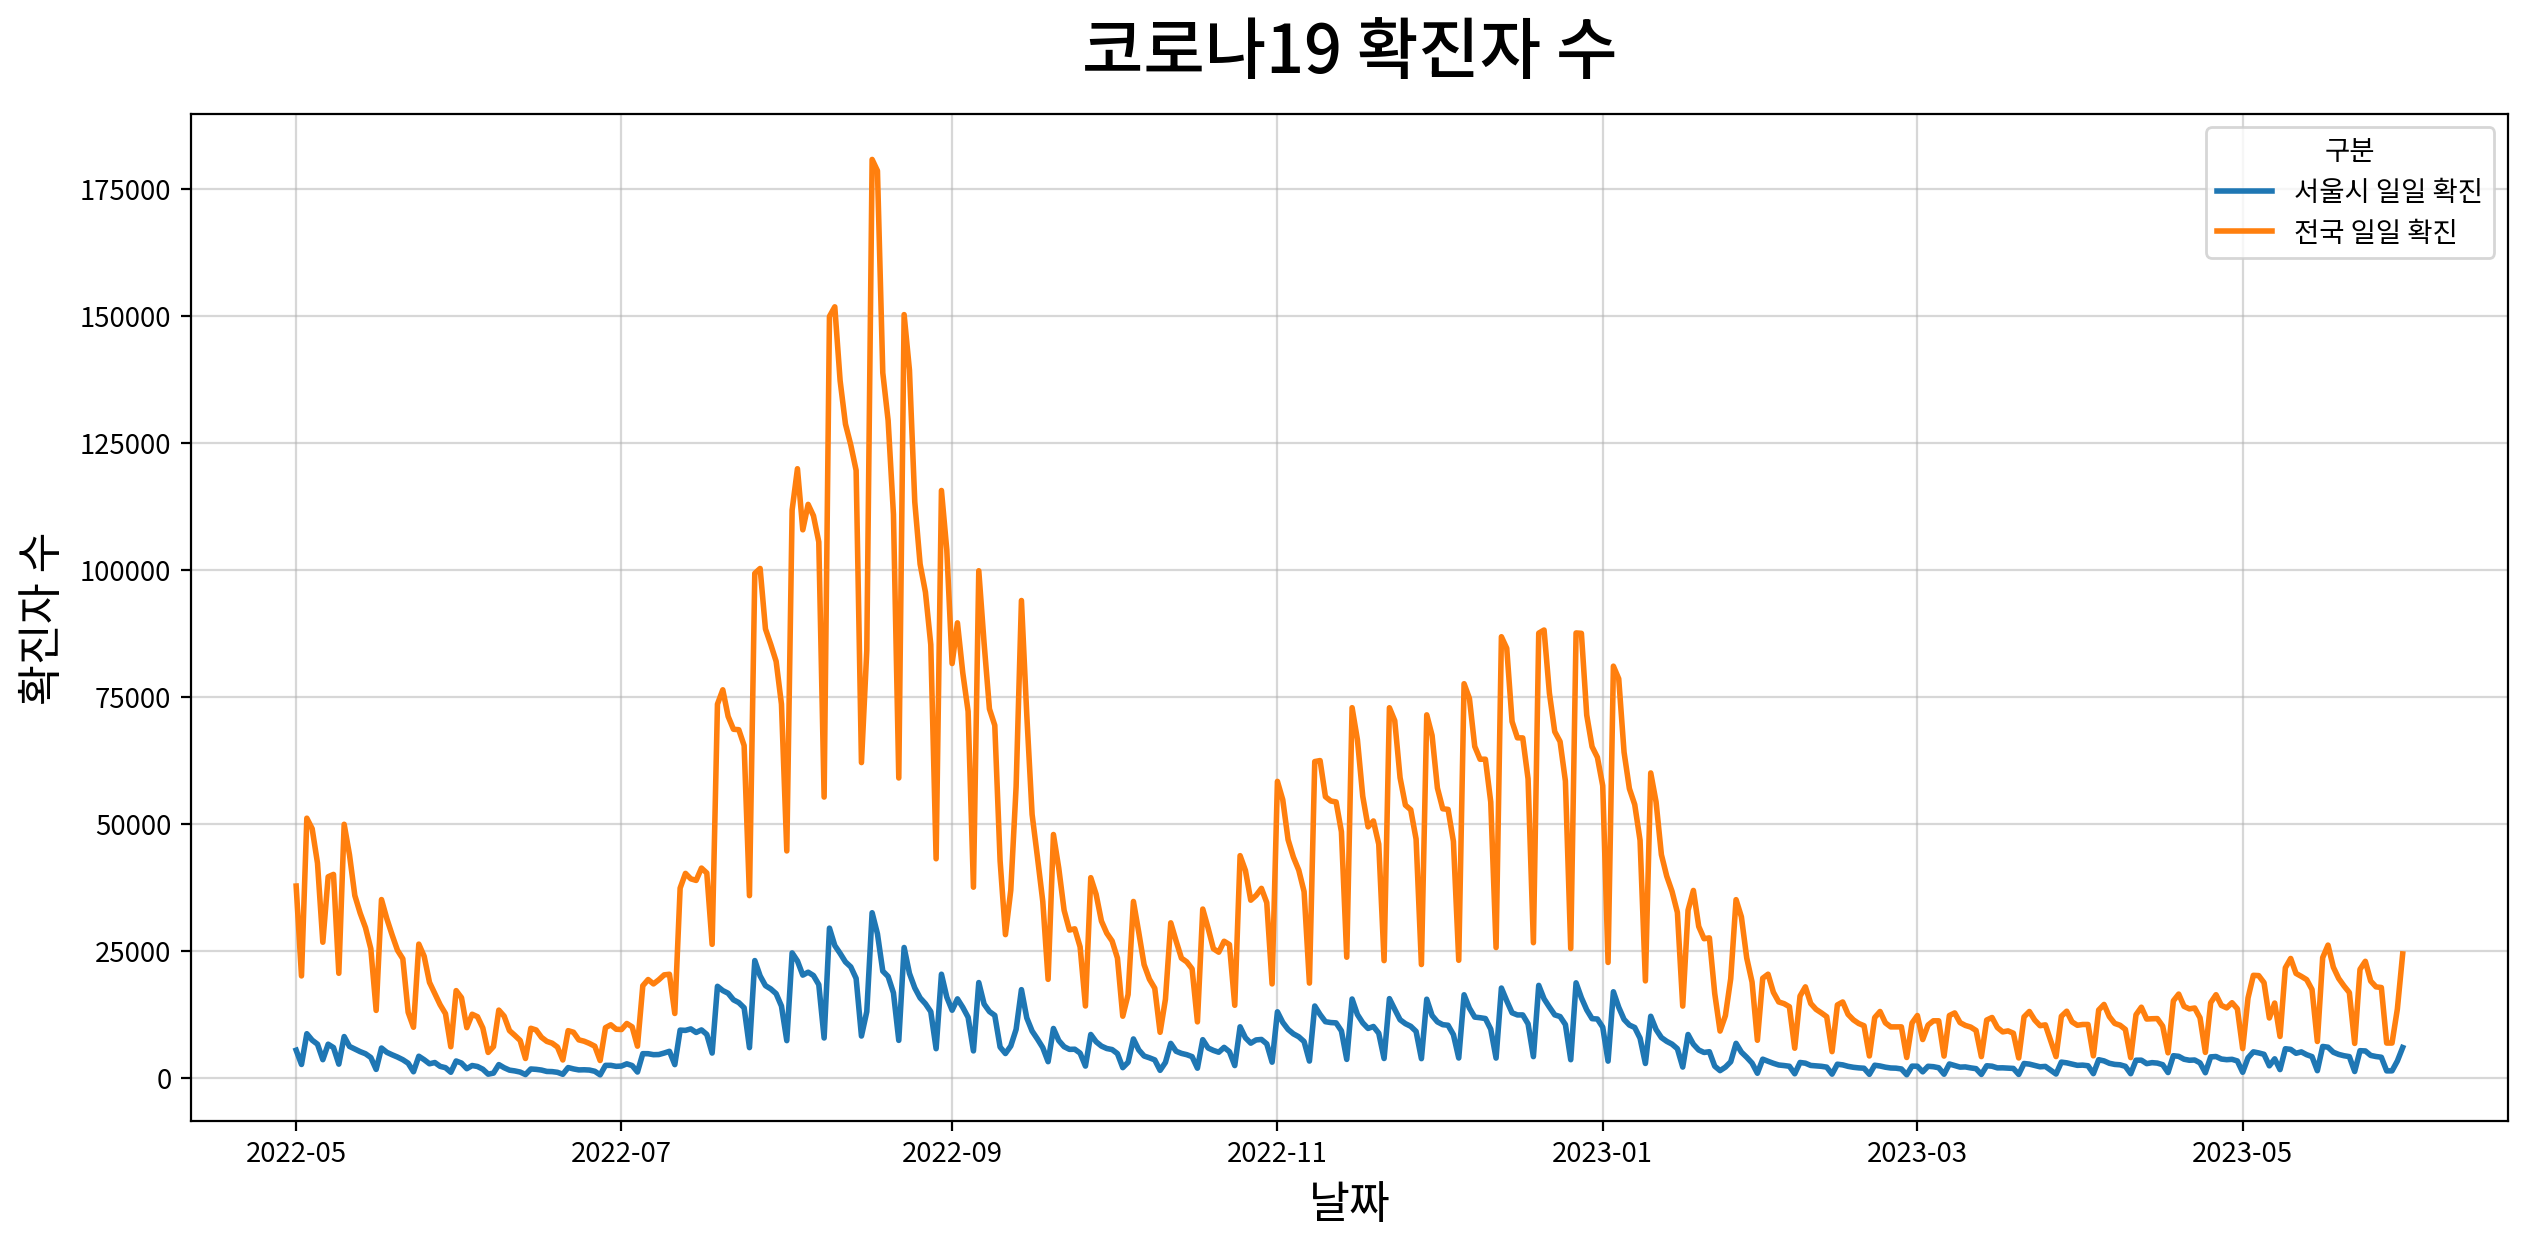

In [5]:
my_plot.lineplot(title="코로나19 확진자 수", xlabel="날짜", ylabel="확진자 수",
                 data=df3, x='기준일', y='확진자 수', hue='구분')

## 문제 풀이

### 문제 1
조사 기간 중 전국 일일 확진자 수가 가장 많았던 시점은 언제인가? (연도와 월)

- **정답**: 2022년 8월
- **해설**: 주황색 선이 가장 높이 솟아오른 구간이 2022-08 부근이다.

### 문제 2

그래프에서 확진자 수의 큰 봉우리(유행 정점)는 총 몇 번 나타났는가?

- **정답**: 2번
- **해설**: 1차 정점(2022년 8월)과 2차 정점(2022년 12월 ~ 2023년 1월)이 관찰된다.

### 문제 3

서울시와 전국의 확진자 수 중, 항상 더 많은 쪽은 어디인가?

- **정답**: 전국
- **해설**: 주황색(전국) 선이 항상 파란색(서울) 선보다 위에 위치한다. 서울은 전국에 포함되는 일부 지역이기 때문이다.